In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import copy # Используем для добавления шума в 1.2.9
from google.colab import files #И спользуем для того чтобы скачать файлы
import os
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8') # Классический стиль оформления графиков в matplotlib
sns.set_palette('Accent') # Устанавливает цветовую палитру для seaborn графиков
%matplotlib inline
#Указывает, что графики должны отображаться прямо в ячейке

df = pd.read_csv('Medical_insurance.csv')
print("Датасет загружен в переменную df")
print(f"Размер (количество записей): {df.shape}")
print(f"Признаки: {list(df.columns)}")
print(f"\nПервые 5 строки таблицы:")
print(df.head(5))

Датасет загружен в переменную df
Размер (количество записей): (2772, 7)
Признаки: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Первые 5 строки таблицы:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [ ]:
# 1.1.	Общее описание

print(f"Количество записей: {df.shape[0]}")
print(f"Количество признаков: {df.shape[1]}")

# Анализ признаков
features_info = []
for col in df.columns:
    col_type = df[col].dtype
    if col_type == 'object':
        examples = df[col].iloc[:3].tolist()
        unique_count = df[col].nunique()
        range_info = f"{unique_count} категорий"
    else:
        examples = df[col].iloc[:3].tolist()
        range_info = f"{df[col].min():.1f} – {df[col].max():.1f}"

    features_info.append({
        'Признак': col,
        'Тип данных': col_type,
        'Диапазон/категории': range_info,
        'Примеры значений': str(examples)
    })

features_df = pd.DataFrame(features_info)
print(features_df.to_string(index=False))

# Анализ пропусков
print("\nАнализ пропущенных значений")
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    'Признак': df.columns,
    'Количество пропусков': missing_count.values,
    'Доля пропусков, %': missing_percent.values
})
print(missing_table.to_string(index=False))

if missing_count.sum() == 0:
    print("\nВывод: пропущенные значения отсутствуют.")
else:
    print(f"\nВывод: обнаружено пропусков: {missing_count.sum()}")

Количество записей: 2772
Количество признаков: 7
 Признак Тип данных Диапазон/категории                        Примеры значений
     age      int64        18.0 – 64.0                            [19, 18, 28]
     sex     object        2 категорий              ['female', 'male', 'male']
     bmi    float64        16.0 – 53.1                     [27.9, 33.77, 33.0]
children      int64          0.0 – 5.0                               [0, 1, 3]
  smoker     object        2 категорий                     ['yes', 'no', 'no']
  region     object        4 категорий ['southwest', 'southeast', 'southeast']
 charges    float64   1121.9 – 63770.4        [16884.924, 1725.5523, 4449.462]

Анализ пропущенных значений
 Признак  Количество пропусков  Доля пропусков, %
     age                     0                0.0
     sex                     0                0.0
     bmi                     0                0.0
children                     0                0.0
  smoker                     0          

Пункт 1.2.1. Диаграммы распределения 
Числовые признаки: ['age', 'bmi', 'children', 'charges']


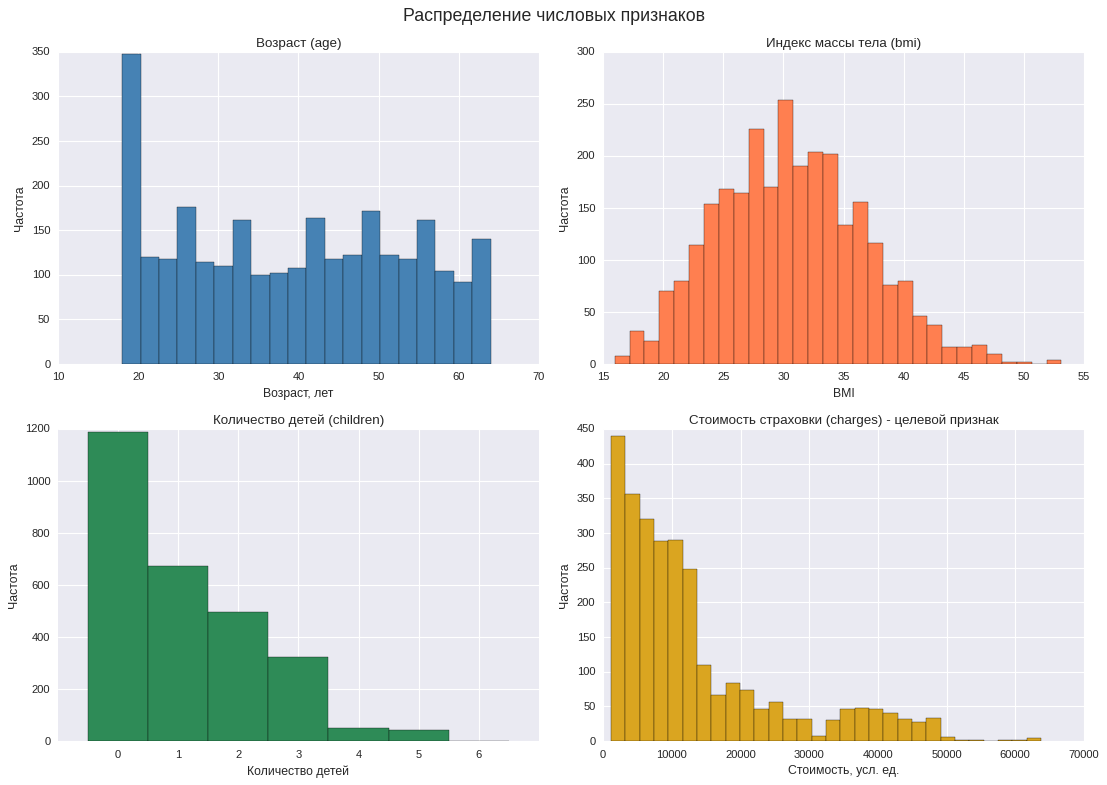

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1.2.	Характеристика числовых данных

print("Пункт 1.2.1. Диаграммы распределения ")

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовые признаки: {numeric_cols}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределение числовых признаков', fontsize=16)

# age
axes[0, 0].hist(df['age'], bins=20, edgecolor='black', color='steelblue')
axes[0, 0].set_title('Возраст (age)', fontsize=12)
axes[0, 0].set_xlabel('Возраст, лет')
axes[0, 0].set_ylabel('Частота')

# bmi
axes[0, 1].hist(df['bmi'], bins=30, edgecolor='black', color='coral')
axes[0, 1].set_title('Индекс массы тела (bmi)', fontsize=12)
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('Частота')

# children
axes[1, 0].hist(df['children'], bins=range(0, 8), edgecolor='black',
                 align='left', color='seagreen')
axes[1, 0].set_title('Количество детей (children)', fontsize=12)
axes[1, 0].set_xlabel('Количество детей')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_xticks(range(0, 7))

# charges
axes[1, 1].hist(df['charges'], bins=30, edgecolor='black', color='goldenrod')
axes[1, 1].set_title('Стоимость страховки (charges) - целевой признак', fontsize=12)
axes[1, 1].set_xlabel('Стоимость, усл. ед.')
axes[1, 1].set_ylabel('Частота')

plt.tight_layout()
plt.savefig('1_distribution_histograms.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('1_distribution_histograms.png')

Пункт 1.2.2. Визуализация seaborn


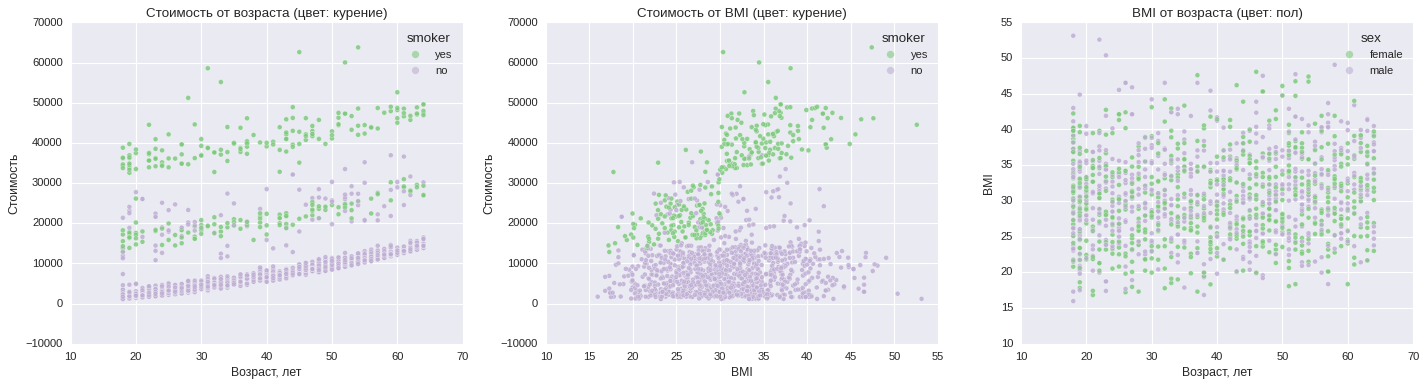

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1.2.2. Визуализация признаков средствами библиотеки seaborn

print("Пункт 1.2.2. Визуализация seaborn")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Пара 1: age vs charges (цвет: smoker)
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.6, ax=axes[0])
axes[0].set_title('Стоимость от возраста (цвет: курение)')
axes[0].set_xlabel('Возраст, лет')
axes[0].set_ylabel('Стоимость')

# Пара 2: bmi vs charges (цвет: smoker)
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6, ax=axes[1])
axes[1].set_title('Стоимость от BMI (цвет: курение)')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Стоимость')

# Пара 3: age vs bmi (цвет: sex)
sns.scatterplot(data=df, x='age', y='bmi', hue='sex', alpha=0.6, ax=axes[2])
axes[2].set_title('BMI от возраста (цвет: пол)')
axes[2].set_xlabel('Возраст, лет')
axes[2].set_ylabel('BMI')

plt.tight_layout()
plt.savefig('2_seaborn_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('2_seaborn_scatter.png')


In [ ]:
# 1.2.3. Визуализация признаков средствами библиотеки pyplot

print("1.2.3. Визуализация признаков средствами библиотеки pyplot")

fig1 = px.scatter_3d(df, x='age', y='bmi', z='charges',
                     color='smoker', symbol='sex',
                     title='3D: стоимость от возраста и BMI')
fig1.show()

# График 2: Boxplot по регионам
fig2 = px.box(df, x='region', y='charges', color='smoker',
              title='Стоимость страховки по регионам')
fig2.show()

1.2.3. Визуализация признаков средствами библиотеки pyplot


1.2.5.	Построение тепловой карты 


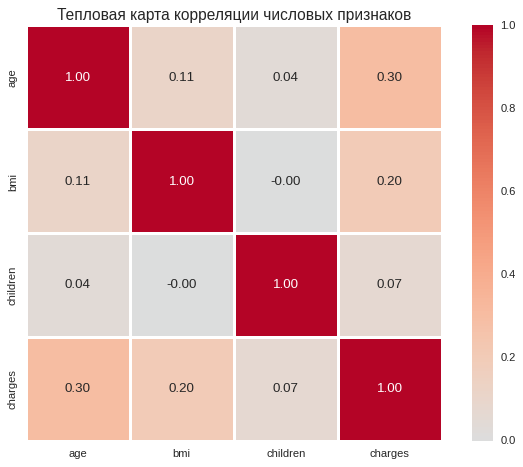

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

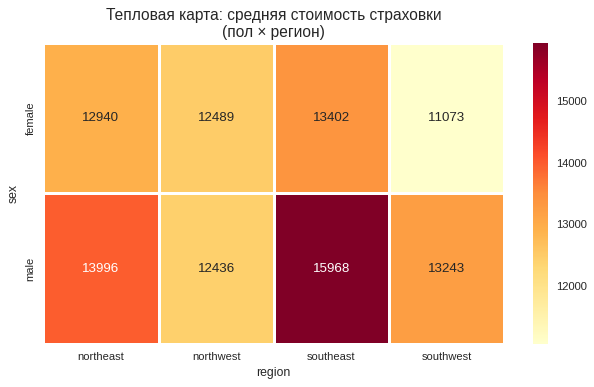

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

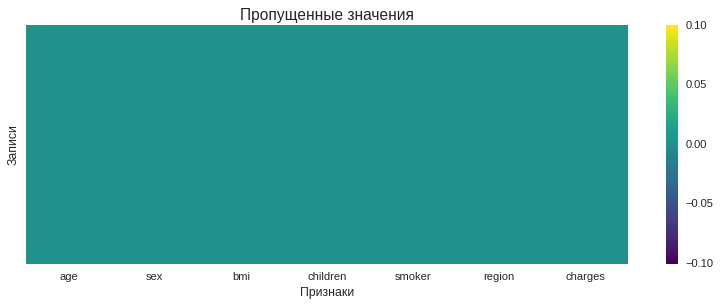

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1.2.5. Построение тепловой карты

print("1.2.5.	Построение тепловой карты ")

# Тепловая карта 1: Корреляция числовых признаков
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=1)
plt.title('Тепловая карта корреляции числовых признаков', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('heatmap_correlation.png')

# Тепловая карта 2: средния стоимость страховки по полу и региону
pivot_table = df.pivot_table(values='charges', index='sex', columns='region', aggfunc='mean')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=1)
plt.title('Тепловая карта: средняя стоимость страховки\n(пол × регион)', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_sex_region.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('heatmap_sex_region.png')

# Тепловая карта 3: пропуски
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Пропущенные значения', fontsize=14)
plt.xlabel('Признаки')
plt.ylabel('Записи')
plt.tight_layout()
plt.savefig('4_heatmap_missing.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('4_heatmap_missing.png')


In [ ]:
# 1.2.6. Устранение дубликатов

print("1.2.6. Устранение дубликатов")

print(f"Исходное количество записей (df): {len(df)}")

duplicates_full = df.duplicated().sum()
print(f"Полные дубликаты (все поля одинаковые): {duplicates_full}")

# Показываем пример дубликата
if duplicates_full > 0:
    print("\nПример полного дубликата:")
    dup_example = df[df.duplicated(keep=False)].sort_values(by=['age', 'sex', 'bmi']).head(4)
    print(dup_example[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']])

# СОЗДАЕМ df_clean - удаляем полные дубликаты
df_clean = df.drop_duplicates().reset_index(drop=True)

print(f"\nПосле удаления дубликатов (df_clean): {len(df_clean)} записей")
print(f"Удалено: {duplicates_full}")

# Проверяем дубликаты по ключевым признакам (разные цены)
key_cols = ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
duplicates_key = df_clean.duplicated(subset=key_cols).sum()
print(f"\nДубликаты по характеристикам (разные цены): {duplicates_key}")

if duplicates_key > 0:
    print("\nПример одинаковых характеристик с разной ценой:")
    dup_example2 = df_clean[df_clean.duplicated(subset=key_cols, keep=False)].sort_values(key_cols).head(6)
    print(dup_example2[['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']])
else:
    print("\nПосле удаления полных дубликатов повторяющихся характеристик нет.")

print("\nВывод: Дальнейший анализ выполняется на df_clean (уникальные записи)")

1.2.6. Устранение дубликатов
Исходное количество записей (df): 2772
Полные дубликаты (все поля одинаковые): 1435

Пример полного дубликата:
      age     sex    bmi  children smoker     region     charges
359    18  female  20.79         0     no  southeast   1607.5101
1745   18  female  20.79         0     no  southeast   1607.5101
1282   18  female  21.66         0    yes  northeast  14283.4594
2668   18  female  21.66         0    yes  northeast  14283.4594

После удаления дубликатов (df_clean): 1337 записей
Удалено: 1435

Дубликаты по характеристикам (разные цены): 2

Пример одинаковых характеристик с разной ценой:
     age     sex     bmi  children smoker     region      charges
102   18  female  30.115         0     no  northeast  21344.84670
471   18  female  30.115         0     no  northeast   2203.47185
181   18  female  38.280         0     no  southeast   1631.82120
354   18  female  38.280         0     no  southeast  14133.03775

Вывод: Дальнейший анализ выполняется на df

1.2.7.	Появление нетипичных выбросов по признакам


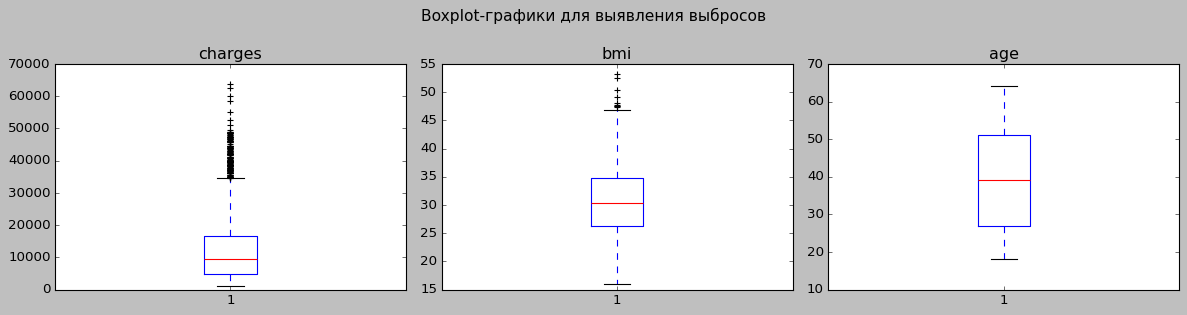

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


charges:
  Q1 = 4746.34, Q3 = 16657.72, IQR = 11911.37
  Нижняя граница: -13120.72
  Верхняя граница: 34524.78
  Выбросов: 139 (10.4%)

bmi:
  Q1 = 26.29, Q3 = 34.70, IQR = 8.41
  Нижняя граница: 13.67
  Верхняя граница: 47.32
  Выбросов: 9 (0.7%)

age:
  Q1 = 27.00, Q3 = 51.00, IQR = 24.00
  Нижняя граница: -9.00
  Верхняя граница: 87.00
  Выбросов: 0 (0.0%)

Краткий вывод: Выбросы есть в charges.


In [ ]:
# 1.2.7. Появление нетипичных выбросов по признакам

print("1.2.7.	Появление нетипичных выбросов по признакам")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].boxplot(df_clean['charges'])
axes[0].set_title('charges')
axes[1].boxplot(df_clean['bmi'])
axes[1].set_title('bmi')
axes[2].boxplot(df_clean['age'])
axes[2].set_title('age')

plt.suptitle('Boxplot-графики для выявления выбросов', fontsize=14)
plt.tight_layout()
plt.savefig('5_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('5_boxplots.png')

for col in ['charges', 'bmi', 'age']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"\n{col}:")
    print(f"  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}")
    print(f"  Нижняя граница: {lower:.2f}")
    print(f"  Верхняя граница: {upper:.2f}")
    print(f"  Выбросов: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

print("\nКраткий вывод: Выбросы есть в charges.")

In [ ]:
# 1.2.8. Условная фильтрация сэмплов

print("1.2.8.	Условная фильтрация сэмплов ")

print("ФИЛЬТР 1: По одному признаку (курильщики)")
print("Условие: smoker == 'yes'")
print("Цель: проанализировать группу клиентов с повышенным риском")

smokers = df_clean[df_clean['smoker'] == 'yes']

print(f"\nРезультат фильтрации:")
print(f"- Количество записей до фильтрации: {len(df_clean)}")
print(f"- Количество записей после фильтрации: {len(smokers)}")
print(f"- Доля от общего числа: {len(smokers)/len(df_clean)*100:.1f}%")

print(f"\nСтатистика по группе курильщиков:")
print(f"- Средний возраст: {smokers['age'].mean():.1f} лет")
print(f"- Средний BMI: {smokers['bmi'].mean():.1f}")
print(f"- Средняя стоимость страховки: {smokers['charges'].mean():.2f}")
print(f"- Соотношение мужчин/женщин: {len(smokers[smokers['sex']=='male'])} / {len(smokers[smokers['sex']=='female'])}")

print(f"\nПервые 5 записей отфильтрованных данных:")
print(smokers[['age', 'sex', 'bmi', 'children', 'region', 'charges']].head())

print("ФИЛЬТР 2: По нескольким признакам (высокорисковые клиенты)")
print("Условия (оба должны выполняться):")
print("  1. age > 50 (возраст старше 50 лет)")
print("  2. bmi > 30 (ожирение)")
print("Цель: выявить клиентов с максимальными рисками для здоровья")

high_risk = df_clean[(df_clean['age'] > 50) & (df_clean['bmi'] > 30)]

print(f"\nРезультат фильтрации:")
print(f"- Количество записей до фильтрации: {len(df_clean)}")
print(f"- Количество записей после фильтрации: {len(high_risk)}")
print(f"- Доля от общего числа: {len(high_risk)/len(df_clean)*100:.1f}%")

print(f"\nСтатистика по группе высокого риска:")
print(f"- Средний возраст: {high_risk['age'].mean():.1f} лет")
print(f"- Средний BMI: {high_risk['bmi'].mean():.1f}")
print(f"- Средняя стоимость страховки: {high_risk['charges'].mean():.2f}")
print(f"- Доля курильщиков: {len(high_risk[high_risk['smoker']=='yes'])/len(high_risk)*100:.1f}%")

print(f"\nПервые 5 записей отфильтрованных данных:")
print(high_risk[['age', 'sex', 'bmi', 'smoker', 'charges']].head())

print("ФИЛЬТР 3: По нескольким признакам (курильщики ИЛИ ожирение)")
print("Условия (достаточно выполнения одного):")
print("  1. smoker == 'yes' (курит)")
print("  2. bmi > 35 (тяжелое ожирение)")
print("Цель: выделить всех клиентов с серьезными факторами риска")

risk_factors = df_clean[(df_clean['smoker'] == 'yes') | (df_clean['bmi'] > 35)]

print(f"\nРезультат фильтрации:")
print(f"- Количество записей до фильтрации: {len(df_clean)}")
print(f"- Количество записей после фильтрации: {len(risk_factors)}")
print(f"- Доля от общего числа: {len(risk_factors)/len(df_clean)*100:.1f}%")

print(f"\nСостав группы:")
smokers_only = len(risk_factors[(risk_factors['smoker'] == 'yes') & (risk_factors['bmi'] <= 35)])
bmi_only = len(risk_factors[(risk_factors['smoker'] == 'no') & (risk_factors['bmi'] > 35)])
both = len(risk_factors[(risk_factors['smoker'] == 'yes') & (risk_factors['bmi'] > 35)])
print(f"- Только курильщики (BMI ≤ 35): {smokers_only}")
print(f"- Только тяжелое ожирение (BMI > 35, не курят): {bmi_only}")
print(f"- Оба фактора: {both}")

print(f"\nСтатистика по группе:")
print(f"- Средний возраст: {risk_factors['age'].mean():.1f} лет")
print(f"- Средний BMI: {risk_factors['bmi'].mean():.1f}")
print(f"- Средняя стоимость страховки: {risk_factors['charges'].mean():.2f}")

print(f"\nПервые 5 записей отфильтрованных данных:")
print(risk_factors[['age', 'sex', 'bmi', 'smoker', 'charges']].head())

1.2.8.	Условная фильтрация сэмплов 
ФИЛЬТР 1: По одному признаку (курильщики)
Условие: smoker == 'yes'
Цель: проанализировать группу клиентов с повышенным риском

Результат фильтрации:
- Количество записей до фильтрации: 1337
- Количество записей после фильтрации: 274
- Доля от общего числа: 20.5%

Статистика по группе курильщиков:
- Средний возраст: 38.5 лет
- Средний BMI: 30.7
- Средняя стоимость страховки: 32050.23
- Соотношение мужчин/женщин: 159 / 115

Первые 5 записей отфильтрованных данных:
    age     sex    bmi  children     region     charges
0    19  female  27.90         0  southwest  16884.9240
11   62  female  26.29         0  southeast  27808.7251
14   27    male  42.13         0  southeast  39611.7577
19   30    male  35.30         0  southwest  36837.4670
23   34  female  31.92         1  northeast  37701.8768
ФИЛЬТР 2: По нескольким признакам (высокорисковые клиенты)
Условия (оба должны выполняться):
  1. age > 50 (возраст старше 50 лет)
  2. bmi > 30 (ожирение)
Цель:

1.2.9.	Добавление шума 

1. Признаки добавления шума:
   - age (возраст) - числовой признак
   - bmi (индекс массы тела) - числовой признак
   Целевой признак charges исключен.

2. Парметры шума:
   age: N(0, 1.404) (10% от std)
   bmi: N(0, 0.305) (5% от std)

3. РЕЗУЛЬТАТЫ (статистика до и после):

   age: исходное mean=39.22, std=14.04
   age: после шума mean=39.28, std=14.09

   bmi: исходное mean=30.66, std=6.10
   bmi: после шума mean=30.67, std=6.10

4. Примеры изменений (первые 5 записей):
 age_orig  age_noisy  bmi_orig  bmi_noisy
       19      19.70    27.900      27.81
       18      17.81    33.770      33.65
       28      28.91    33.000      33.05
       33      35.14    22.705      22.75
       32      31.67    28.880      28.88


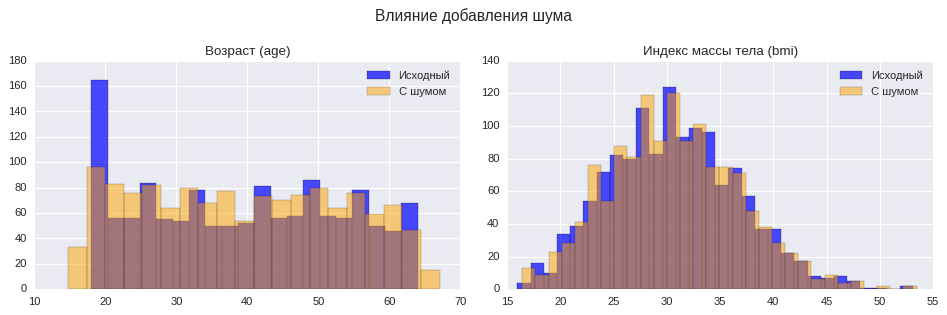

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#1.2.9.	Добавление шума

print("1.2.9.	Добавление шума ")

df_noisy = df_clean.copy()
np.random.seed(42)

# 1. Выбор признаков (исключая целевой)
print("\n1. Признаки добавления шума:")
print("   - age (возраст) - числовой признак")
print("   - bmi (индекс массы тела) - числовой признак")
print("   Целевой признак charges исключен.")

# 2. Параметры шума
age_std = df_clean['age'].std()
bmi_std = df_clean['bmi'].std()

age_noise = np.random.normal(0, age_std * 0.1, len(df_clean))
bmi_noise = np.random.normal(0, bmi_std * 0.05, len(df_clean))

print("\n2. Парметры шума:")
print(f"   age: N(0, {age_std*0.1:.3f}) (10% от std)")
print(f"   bmi: N(0, {bmi_std*0.05:.3f}) (5% от std)")

# 3. Добавление шума
df_noisy['age_noisy'] = df_clean['age'] + age_noise
df_noisy['bmi_noisy'] = df_clean['bmi'] + bmi_noise

print("\n3. РЕЗУЛЬТАТЫ (статистика до и после):")
print(f"\n   age: исходное mean={df_clean['age'].mean():.2f}, std={df_clean['age'].std():.2f}")
print(f"   age: после шума mean={df_noisy['age_noisy'].mean():.2f}, std={df_noisy['age_noisy'].std():.2f}")
print(f"\n   bmi: исходное mean={df_clean['bmi'].mean():.2f}, std={df_clean['bmi'].std():.2f}")
print(f"   bmi: после шума mean={df_noisy['bmi_noisy'].mean():.2f}, std={df_noisy['bmi_noisy'].std():.2f}")

# 4. Примеры изменений
print("\n4. Примеры изменений (первые 5 записей):")
comparison = pd.DataFrame({
    'age_orig': df_clean['age'].iloc[:5].values,
    'age_noisy': df_noisy['age_noisy'].iloc[:5].values.round(2),
    'bmi_orig': df_clean['bmi'].iloc[:5].values,
    'bmi_noisy': df_noisy['bmi_noisy'].iloc[:5].values.round(2)
})
print(comparison.to_string(index=False))

# 5. Графики
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Влияние добавления шума', fontsize=14)

axes[0].hist(df_clean['age'], bins=20, alpha=0.7, label='Исходный', color='blue')
axes[0].hist(df_noisy['age_noisy'], bins=20, alpha=0.5, label='С шумом', color='orange')
axes[0].set_title('Возраст (age)')
axes[0].legend()

axes[1].hist(df_clean['bmi'], bins=30, alpha=0.7, label='Исходный', color='blue')
axes[1].hist(df_noisy['bmi_noisy'], bins=30, alpha=0.5, label='С шумом', color='orange')
axes[1].set_title('Индекс массы тела (bmi)')
axes[1].legend()

plt.tight_layout()
plt.savefig('noise_results.png', dpi=300, bbox_inches='tight')
plt.show()
files.download('noise_results.png')

In [ ]:
# 1.2.10.	Преобразование числовых данных в категориальные

print("1.2.10.	Преобразование числовых данных в категориальные ")

df_categorical = df_clean.copy()

df_categorical['age_group'] = pd.cut(df_categorical['age'],
                                      bins=[0, 20, 30, 40, 50, 60, 100],
                                      labels=['0-20', '21-30', '31-40', '41-50', '51-60', '60+'])
print("\nВозрастные группы:")
print(df_categorical['age_group'].value_counts().sort_index())

# Категории BMI
def bmi_cat(bmi):
    if bmi < 18.5: return 'Недостаточный'
    elif bmi < 25: return 'Нормальный'
    elif bmi < 30: return 'Избыточный'
    else: return 'Ожирение'

df_categorical['bmi_category'] = df_categorical['bmi'].apply(bmi_cat)
print("\nКатегории BMI (bmi_category):")
print(df_categorical['bmi_category'].value_counts())

# Группы детей
df_categorical['children_group'] = df_clean['children'].apply(
    lambda x: '0' if x == 0 else '1' if x == 1 else '2' if x == 2 else '3+')
print("\nГруппы детей (children_group):")
print(df_categorical['children_group'].value_counts().sort_index())

print(df_categorical.head(5))

1.2.10.	Преобразование числовых данных в категориальные 

Возрастные группы:
age_group
0-20     165
21-30    278
31-40    257
41-50    281
51-60    265
60+       91
Name: count, dtype: int64

Категории BMI (bmi_category):
bmi_category
Ожирение         706
Избыточный       386
Нормальный       225
Недостаточный     20
Name: count, dtype: int64

Группы детей (children_group):
children_group
0     573
1     324
2     240
3+    200
Name: count, dtype: int64
   age     sex     bmi  children smoker     region      charges age_group  \
0   19  female  27.900         0    yes  southwest  16884.92400      0-20   
1   18    male  33.770         1     no  southeast   1725.55230      0-20   
2   28    male  33.000         3     no  southeast   4449.46200     21-30   
3   33    male  22.705         0     no  northwest  21984.47061     31-40   
4   32    male  28.880         0     no  northwest   3866.85520     31-40   

  bmi_category children_group  
0   Избыточный              0  
1     Ожирение 

1.2.12. Оценка изменения в данных после фильтрации 

1. Сравнение статистик до и после шума:
Признак   Версия  Среднее  Стд.отклонение
    age Исходный    39.22           14.04
    age  С шумом    39.28           14.09
    bmi Исходный    30.66            6.10
    bmi  С шумом    30.67            6.10


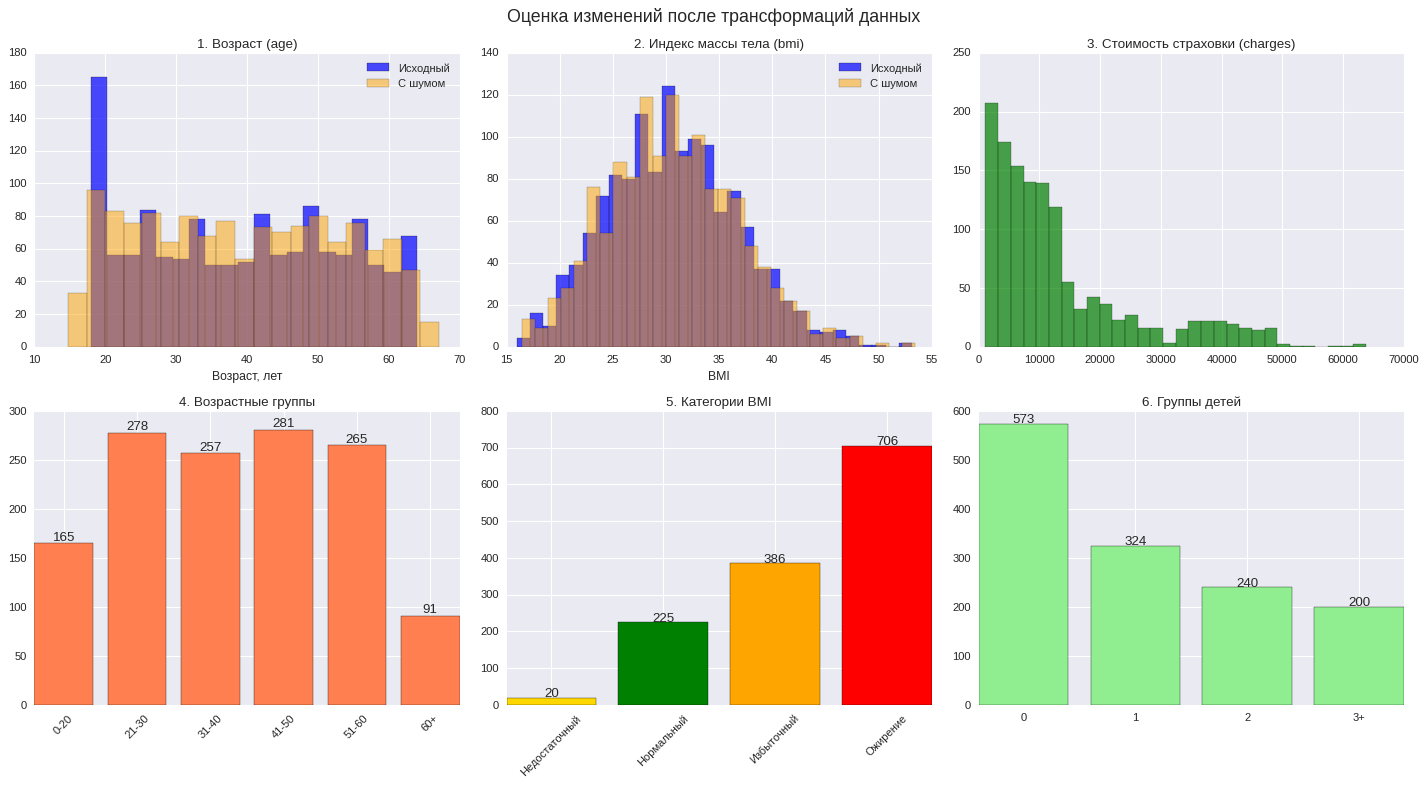

In [ ]:
#1.2.12.	Оценка изменения в данных после фильтрации

print("1.2.12. Оценка изменения в данных после фильтрации ")

print("\n1. Сравнение статистик до и после шума:")
comparison_stats = pd.DataFrame({
    'Признак': ['age', 'age', 'bmi', 'bmi'],
    'Версия': ['Исходный', 'С шумом', 'Исходный', 'С шумом'],
    'Среднее': [
        df_clean['age'].mean(), df_noisy['age_noisy'].mean(),
        df_clean['bmi'].mean(), df_noisy['bmi_noisy'].mean()
    ],
    'Стд.отклонение': [
        df_clean['age'].std(), df_noisy['age_noisy'].std(),
        df_clean['bmi'].std(), df_noisy['bmi_noisy'].std()
    ]
})
print(comparison_stats.round(2).to_string(index=False))

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Оценка изменений после трансформаций данных', fontsize=16)

# График 1: age
axes[0, 0].hist(df_clean['age'], bins=20, alpha=0.7, label='Исходный', color='blue')
axes[0, 0].hist(df_noisy['age_noisy'], bins=20, alpha=0.5, label='С шумом', color='orange')
axes[0, 0].set_title('1. Возраст (age)')
axes[0, 0].set_xlabel('Возраст, лет')
axes[0, 0].legend()

# График 2: bmi
axes[0, 1].hist(df_clean['bmi'], bins=30, alpha=0.7, label='Исходный', color='blue')
axes[0, 1].hist(df_noisy['bmi_noisy'], bins=30, alpha=0.5, label='С шумом', color='orange')
axes[0, 1].set_title('2. Индекс массы тела (bmi)')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].legend()

# График 3: charges
axes[0, 2].hist(df_clean['charges'], bins=30, alpha=0.7, color='green', edgecolor='black')
axes[0, 2].set_title('3. Стоимость страховки (charges)')

# График 4: age_group
age_counts = df_categorical['age_group'].value_counts().sort_index()
bars = axes[1, 0].bar(age_counts.index, age_counts.values, color='coral')
axes[1, 0].set_title('4. Возрастные группы')
axes[1, 0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, age_counts.values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(v), ha='center')

# График 5: bmi_category (ИСПРАВЛЕНО - используем короткие названия)
bmi_order = ['Недостаточный', 'Нормальный', 'Избыточный', 'Ожирение']
bmi_counts = df_categorical['bmi_category'].value_counts()
bmi_counts = bmi_counts.reindex(bmi_order, fill_value=0)
bars = axes[1, 1].bar(bmi_counts.index, bmi_counts.values,
                       color=['gold', 'green', 'orange', 'red'])
axes[1, 1].set_title('5. Категории BMI')
axes[1, 1].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, bmi_counts.values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(v), ha='center')

# График 6: children_group
children_order = ['0', '1', '2', '3+']
children_counts = df_categorical['children_group'].value_counts()
children_counts = children_counts.reindex(children_order, fill_value=0)
bars = axes[1, 2].bar(children_counts.index, children_counts.values, color='lightgreen')
axes[1, 2].set_title('6. Группы детей')
for bar, v in zip(bars, children_counts.values):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3, str(v), ha='center')

plt.tight_layout()
plt.savefig('transformations_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 1.3.	Характеристика категориальных данных

print("1.3.1.	Перечислить все категории по признакам ")

categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Категориальные признаки: {categorical_cols}")

print("\n--- Категории ---")
for col in categorical_cols:
    categories = df_clean[col].unique().tolist()
    counts = df_clean[col].value_counts()
    print(f"\n{col}:")
    print(f"  Категории: {categories}")
    print(f"  Количество категорий: {len(categories)}")
    print(f"  Распределение:")
    for cat in categories:
        print(f"    - '{cat}': {counts[cat]} ({counts[cat]/len(df_clean)*100:.1f}%)")

1.3.1.	Перечислить все категории по признакам 
Категориальные признаки: ['sex', 'smoker', 'region']

--- КАТЕГОРИИ ПО ПРИЗНАКАМ ---

sex:
  Категории: ['female', 'male']
  Количество категорий: 2
  Распределение:
    - 'female': 662 (49.5%)
    - 'male': 675 (50.5%)

smoker:
  Категории: ['yes', 'no']
  Количество категорий: 2
  Распределение:
    - 'yes': 274 (20.5%)
    - 'no': 1063 (79.5%)

region:
  Категории: ['southwest', 'southeast', 'northwest', 'northeast']
  Количество категорий: 4
  Распределение:
    - 'southwest': 325 (24.3%)
    - 'southeast': 364 (27.2%)
    - 'northwest': 324 (24.2%)
    - 'northeast': 324 (24.2%)


1.3.2.	Диаграммы распределения категориальных данных


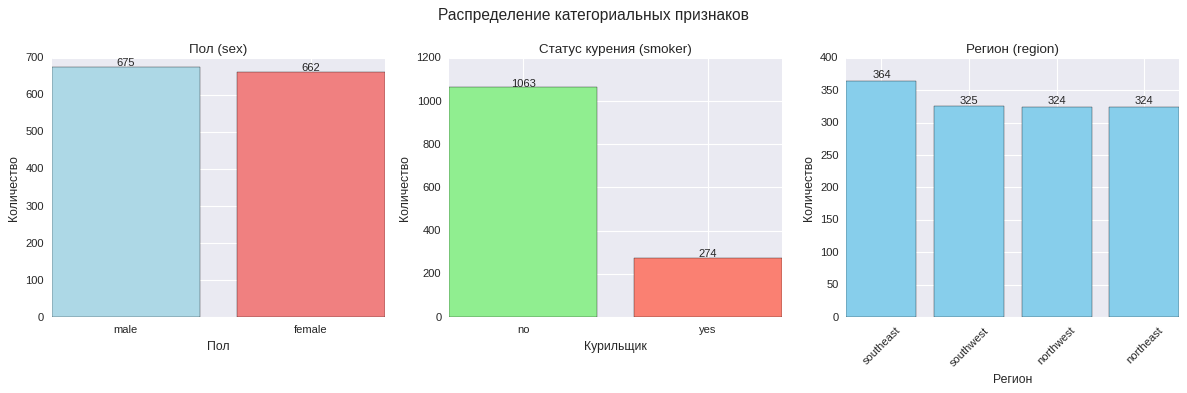

In [ ]:
# 1.3.2.	Диаграммы распределения категориальных данных

print("1.3.2.	Диаграммы распределения категориальных данных")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Распределение категориальных признаков', fontsize=14)

# График 1: Пол
sex_counts = df_clean['sex'].value_counts()
bars = axes[0].bar(sex_counts.index, sex_counts.values, color=['lightblue', 'lightcoral'])
axes[0].set_title('Пол (sex)')
axes[0].set_xlabel('Пол')
axes[0].set_ylabel('Количество')
for bar, v in zip(bars, sex_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=10)

# График 2: Статус курения
smoker_counts = df_clean['smoker'].value_counts()
bars = axes[1].bar(smoker_counts.index, smoker_counts.values, color=['lightgreen', 'salmon'])
axes[1].set_title('Статус курения (smoker)')
axes[1].set_xlabel('Курильщик')
axes[1].set_ylabel('Количество')
for bar, v in zip(bars, smoker_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=10)

# График 3: Регион
region_counts = df_clean['region'].value_counts()
bars = axes[2].bar(region_counts.index, region_counts.values, color='skyblue')
axes[2].set_title('Регион (region)')
axes[2].set_xlabel('Регион')
axes[2].set_ylabel('Количество')
axes[2].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, region_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('categorical_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 1.3.3. Преобразование категориальных данных в числовые

print("1.3.3. Преобразование категориальных данных в числовые ")

df_encoded = df_clean.copy()

# 1. Label Encoding (для бинарных признаков)
print("\n1. Label Encoding (для бинарных признаков):")
df_encoded['sex_label'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker_label'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
print("   sex: male → 1, female → 0")
print("   smoker: yes → 1, no → 0")
print(df_encoded[['sex', 'sex_label', 'smoker', 'smoker_label']].head(3))

# 2. One-Hot Encoding (для региона)
print("\n2.One-Hot Encoding (для региона)")
region_dummies = pd.get_dummies(df_encoded['region'], prefix='', dtype=int)
df_encoded = pd.concat([df_encoded, region_dummies], axis=1)
df_encoded = df_encoded.drop('region', axis=1)
region_cols = list(region_dummies.columns)
print(df_encoded[region_cols].head(5).to_string())

# 3. Frequency Encoding (для всех категориальных признаков)
print("\n3. Frequency Encoding (для всех категориальных признаков):")
for col in ['sex', 'smoker', 'region']:
    freq_map = df_clean[col].value_counts(normalize=True).to_dict()
    df_encoded[f'{col}_freq'] = df_clean[col].map(freq_map)
    print(f"   {col}:")
    for cat, freq in freq_map.items():
        print(f"      {cat}: {freq:.3f} ({freq*100:.1f}%)")

1.3.3. Преобразование категориальных данных в числовые 

1. Label Encoding (для бинарных признаков):
   sex: male → 1, female → 0
   smoker: yes → 1, no → 0
      sex  sex_label smoker  smoker_label
0  female          0    yes             1
1    male          1     no             0
2    male          1     no             0

2.One-Hot Encoding (для региона)
   _northeast  _northwest  _southeast  _southwest
0           0           0           0           1
1           0           0           1           0
2           0           0           1           0
3           0           1           0           0
4           0           1           0           0

3. Frequency Encoding (для всех категориальных признаков):
   sex:
      male: 0.505 (50.5%)
      female: 0.495 (49.5%)
   smoker:
      no: 0.795 (79.5%)
      yes: 0.205 (20.5%)
   region:
      southeast: 0.272 (27.2%)
      southwest: 0.243 (24.3%)
      northwest: 0.242 (24.2%)
      northeast: 0.242 (24.2%)


In [ ]:
#1.3.4.	Агрегация данных

print("1.3.4.	Агрегация данных ")

rare_threshold = 0.05  # 5%

print("Анализ категорий на редкость (менее 5%):\n")

for col in ['sex', 'smoker', 'region']:
    counts = df_clean[col].value_counts()
    total = len(df_clean)
    min_pct = counts.min() / total * 100

    print(f"{col}:")
    print(f"  Всего категорий: {len(counts)}")
    print(f"  Минимальная доля: {min_pct:.1f}%")

    if min_pct >= 5:
        print(f"  Редкие категории (менее 5%): отсутствуют")
    else:
        rare_cats = counts[counts / total < rare_threshold]
        print(f"  Редкие категории: {list(rare_cats.index)}")
    print()


1.3.4.	Агрегация данных 
Анализ категорий на редкость (менее 5%):

sex:
  Всего категорий: 2
  Минимальная доля: 49.5%
  Редкие категории (менее 5%): отсутствуют

smoker:
  Всего категорий: 2
  Минимальная доля: 20.5%
  Редкие категории (менее 5%): отсутствуют

region:
  Всего категорий: 4
  Минимальная доля: 24.2%
  Редкие категории (менее 5%): отсутствуют



1.3.5.	Введение новой категории

Создание новой категории - Группа риска

Распределение по группам риска:
  Низкий: 392 (29.3%)
  Средний: 594 (44.4%)
  Высокий: 313 (23.4%)
  Очень высокий: 38 (2.8%)

Средняя стоимость страховки по группам риска:
  Низкий: 6476.67
  Средний: 10171.47
  Высокий: 23557.36
  Очень высокий: 47369.07


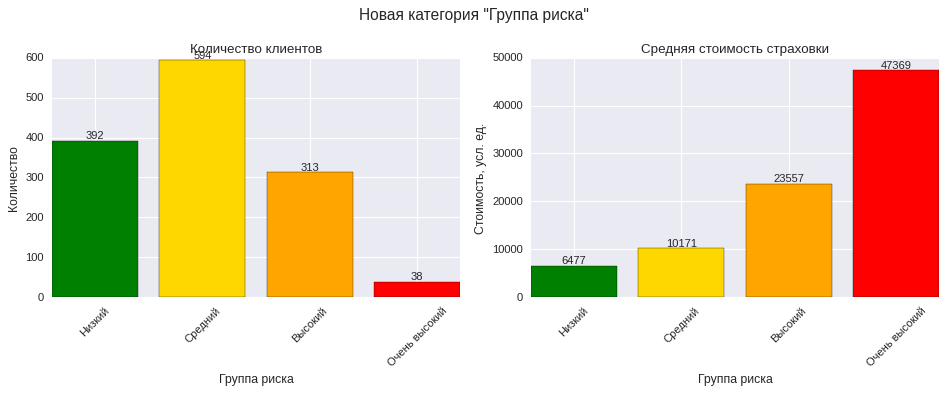

In [ ]:
# 1.3.5.	Введение новой категории

print("1.3.5.	Введение новой категории")

df_new = df_clean.copy()

# Создание новой категории "Группа риска"
# Обобщает 3 признака: курение, ожирение, возраст

print("\nСоздание новой категории - Группа риска")

def risk_group(row):
    score = 0
    if row['smoker'] == 'yes':
        score += 1
    if row['bmi'] > 30:
        score += 1
    if row['age'] > 50:
        score += 1

    if score == 0:
        return 'Низкий'
    elif score == 1:
        return 'Средний'
    elif score == 2:
        return 'Высокий'
    else:
        return 'Очень высокий'

df_new['risk_group'] = df_new.apply(risk_group, axis=1)

# Результаты
print("\nРаспределение по группам риска:")
risk_counts = df_new['risk_group'].value_counts()
risk_order = ['Низкий', 'Средний', 'Высокий', 'Очень высокий']
risk_counts = risk_counts.reindex(risk_order)

for group in risk_order:
    count = risk_counts[group]
    print(f"  {group}: {count} ({count/len(df_new)*100:.1f}%)")

print("\nСредняя стоимость страховки по группам риска:")
risk_charges = df_new.groupby('risk_group')['charges'].mean().reindex(risk_order)
for group in risk_order:
    print(f"  {group}: {risk_charges[group]:.2f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Новая категория "Группа риска"', fontsize=14)

# График 1: количество
colors = ['green', 'gold', 'orange', 'red']
bars = axes[0].bar(risk_counts.index, risk_counts.values, color=colors)
axes[0].set_title('Количество клиентов')
axes[0].set_xlabel('Группа риска')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(v), ha='center', fontsize=10)

# График 2: средняя стоимость
bars = axes[1].bar(risk_charges.index, risk_charges.values, color=colors)
axes[1].set_title('Средняя стоимость страховки')
axes[1].set_xlabel('Группа риска')
axes[1].set_ylabel('Стоимость, усл. ед.')
axes[1].tick_params(axis='x', rotation=45)
for bar, v in zip(bars, risk_charges.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
                 f"{v:.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('risk_group_new.png', dpi=300, bbox_inches='tight')
plt.show()
